In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.interpolate import make_smoothing_spline
from scipy.ndimage import gaussian_filter
import plotly.graph_objects as go
from typing import Iterable, Optional, Tuple, List, Literal

In [2]:
oae = xr.open_dataset("c:\\Users\\junsu\\my_project\\data\\OAE_efficiency_maps_alltime.nc")

oae_df = oae.to_dataframe()
oae_df = oae_df.reset_index().pivot(
    index="N_month", columns=["TLAT", "TLONG", "season"], values="OAE_efficiency"
)
oae_df.dropna(axis=1, how="all", inplace=True)
oae_diffed = oae_df - oae_df.shift().fillna(0)

## Empirical Analysis

In [3]:
oae_diffed = oae_diffed.loc[2:]

In [4]:
X_t0 = oae_diffed.iloc[:-1].to_numpy().flatten()
X_t1 = oae_diffed.iloc[1:].to_numpy().flatten()
finite_mask = np.isfinite(X_t0) & np.isfinite(X_t1)

In [5]:
cal_month = (
    oae_diffed.index.to_numpy()[:,np.newaxis] + oae_diffed.columns.get_level_values(2).map({"January": 1, "April": 4, "July": 7, "October": 10}).to_numpy()[np.newaxis,:]
)[:-1].flatten() % 12
season = np.abs(cal_month - 6)
season = 2 * season / season.max() - 1

In [6]:
latitude_0 = np.tile(oae_diffed.columns.get_level_values(0).to_numpy(), len(oae_diffed) - 1)
longitude_0 = np.tile(oae_diffed.columns.get_level_values(1).to_numpy(), len(oae_diffed) - 1)

latitude = latitude_0.round(1)
longitude = longitude_0.round(1)

time = np.repeat(oae_diffed.index.to_numpy()[:-1], len(oae_diffed.columns))
time = time / time.max()

In [7]:
a_bound = [0, 1.5]
b_bound = [0, 100]
c_bound = [-5, 0]
d_bound = [-1, 1]
e_bound = [-0.5, 0.5]
f_bound = [-0.5, 0.5]

def ar_model(
        X: np.ndarray,
        a: float,
        b: float,
        c: float,
        d: float,
        e: float,
        f: float,
    ) -> np.ndarray:
    return (a / (1 + np.exp(b*(X[:, 0] + c))) + d + e*X[:, 1]) * X[:, 2] + f

unique_latitude = np.unique(latitude)
optimal_params = np.zeros((len(unique_latitude), 6))

residuals = np.full_like(X_t1, np.nan, dtype=np.float64)
r_sq = np.zeros(len(unique_latitude))

popt = [1, 1, -0.5, 0, 0, 0]
for i, lat in enumerate(unique_latitude):
    print(f"Fitting for latitude = {lat:.1f}")
    lat_bw = 1.0
    mask = (lat - lat_bw <= latitude) & (latitude <= lat + lat_bw) & finite_mask
    X = np.column_stack((time[mask], season[mask], X_t0[mask]))
    popt, pcov = curve_fit(
        ar_model,
        X,
        X_t1[mask],
        p0=popt,
        bounds=(
            [a_bound[0], b_bound[0], c_bound[0], d_bound[0], e_bound[0], f_bound[0]],
            [a_bound[1], b_bound[1], c_bound[1], d_bound[1], e_bound[1], f_bound[1]],
        ),
    )
    optimal_params[i] = popt
    residuals[mask] = X_t1[mask] - ar_model(X, *popt)
    ss_res = np.sum(residuals[mask]**2)
    ss_tot = np.sum((X_t1[mask] - np.mean(X_t1[mask]))**2)
    r_sq[i] = 1 - (ss_res / ss_tot)

Fitting for latitude = -78.2
Fitting for latitude = -77.6
Fitting for latitude = -77.1
Fitting for latitude = -76.5
Fitting for latitude = -76.0
Fitting for latitude = -75.5
Fitting for latitude = -74.9
Fitting for latitude = -74.4
Fitting for latitude = -73.9
Fitting for latitude = -73.3
Fitting for latitude = -72.8
Fitting for latitude = -72.3
Fitting for latitude = -71.7
Fitting for latitude = -71.2
Fitting for latitude = -70.7
Fitting for latitude = -70.1
Fitting for latitude = -69.6
Fitting for latitude = -69.1
Fitting for latitude = -68.5
Fitting for latitude = -68.0
Fitting for latitude = -67.5
Fitting for latitude = -66.9
Fitting for latitude = -66.4
Fitting for latitude = -65.9
Fitting for latitude = -65.3
Fitting for latitude = -64.8
Fitting for latitude = -64.3
Fitting for latitude = -63.7
Fitting for latitude = -63.2
Fitting for latitude = -62.7
Fitting for latitude = -62.1
Fitting for latitude = -61.6
Fitting for latitude = -61.1
Fitting for latitude = -60.5
Fitting for la

In [8]:
lam = 2000
optimal_param_0_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 0], lam=lam)
optimal_param_1_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 1], lam=lam)
optimal_param_2_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 2], lam=lam)
optimal_param_3_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 3], lam=lam)
optimal_param_4_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 4], lam=lam)
optimal_param_5_spl = make_smoothing_spline(unique_latitude, optimal_params[:, 5], lam=lam)

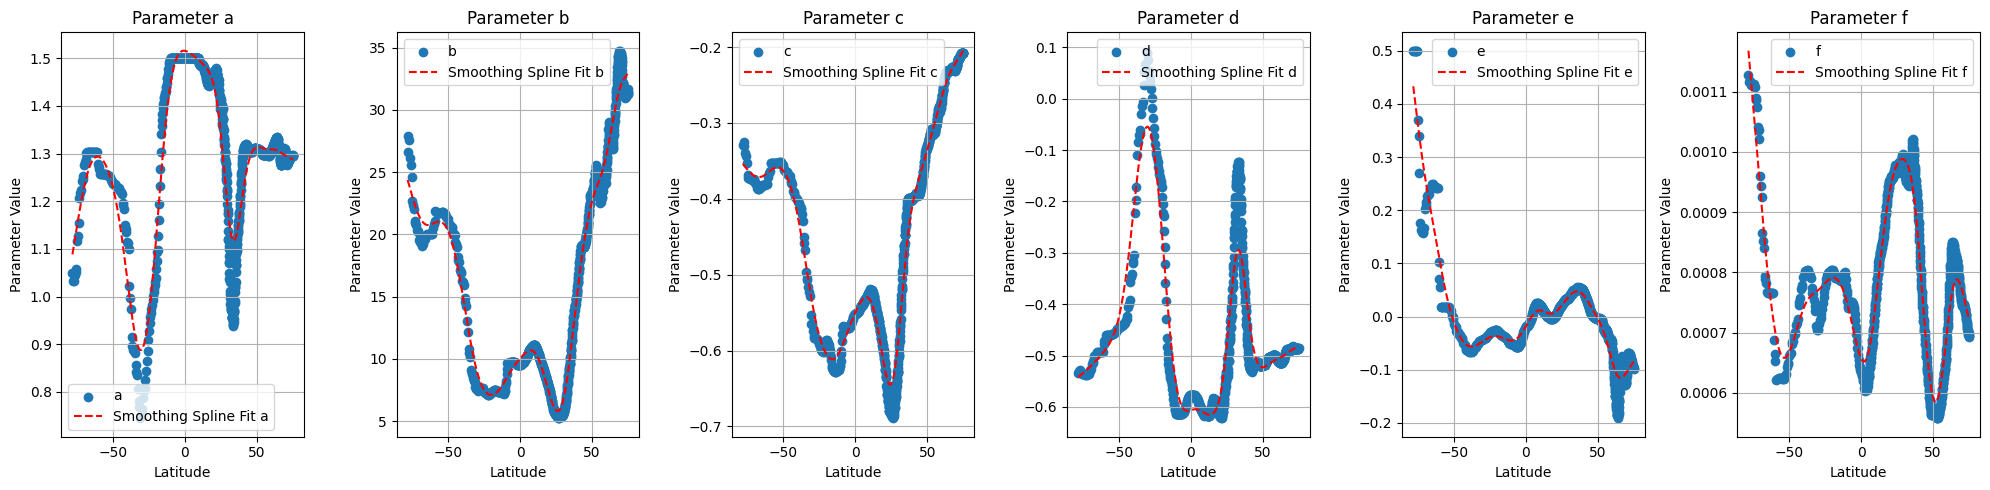

In [9]:
fig, ax = plt.subplots(1, 6, figsize=(20, 5))

ax[0].scatter(unique_latitude, optimal_params[:, 0], label="a")
ax[0].plot(unique_latitude, optimal_param_0_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit a')
ax[0].set_title("Parameter a")

ax[1].scatter(unique_latitude, optimal_params[:, 1], label="b")
ax[1].plot(unique_latitude, optimal_param_1_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit b')
ax[1].set_title("Parameter b")

ax[2].scatter(unique_latitude, optimal_params[:, 2], label="c")
ax[2].plot(unique_latitude, optimal_param_2_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit c')
ax[2].set_title("Parameter c")

ax[3].scatter(unique_latitude, optimal_params[:, 3], label="d")
ax[3].plot(unique_latitude, optimal_param_3_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit d')
ax[3].set_title("Parameter d")

ax[4].scatter(unique_latitude, optimal_params[:, 4], label="e")
ax[4].plot(unique_latitude, optimal_param_4_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit e')
ax[4].set_title("Parameter e")

ax[5].scatter(unique_latitude, optimal_params[:, 5], label="f")
ax[5].plot(unique_latitude, optimal_param_5_spl(unique_latitude), color='red', linestyle='--', label='Smoothing Spline Fit f')
ax[5].set_title("Parameter f")

for i in range(6):
    ax[i].set_xlabel("Latitude")
    ax[i].set_ylabel("Parameter Value")
    ax[i].grid(True)
    ax[i].legend()
plt.tight_layout()
plt.show()

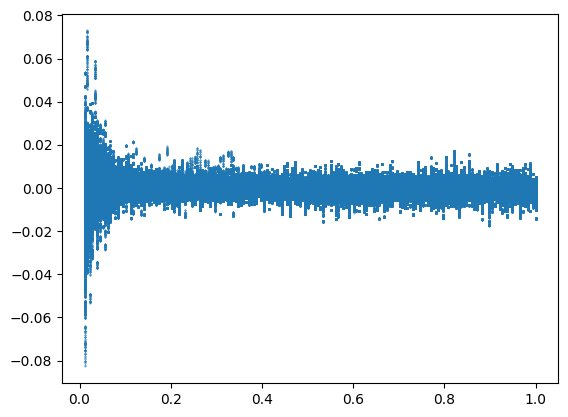

In [10]:
plt.scatter(time, residuals, s=0.1)

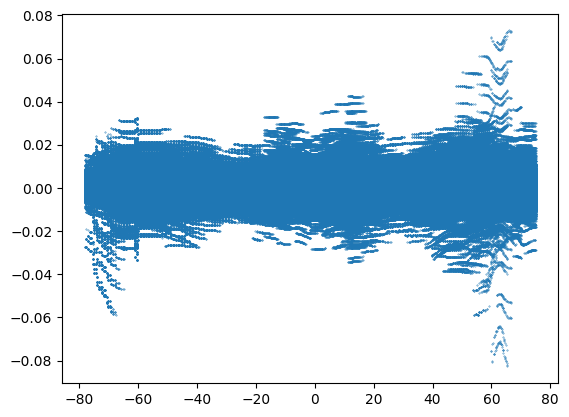

In [11]:
plt.scatter(latitude, residuals, s=0.1)

In [12]:
resd_mean_by_lat = pd.Series(residuals, index=latitude).groupby(latitude).mean()
resd_mean_by_lon = pd.Series(residuals, index=longitude).groupby(longitude).mean()
resd_mean_by_time = pd.Series(residuals, index=time).groupby(time).mean()

resd_std_by_lat = pd.Series(residuals, index=latitude).groupby(latitude).std()
resd_std_by_lon = pd.Series(residuals, index=longitude).groupby(longitude).std()
resd_std_by_time = pd.Series(residuals, index=time).groupby(time).std()

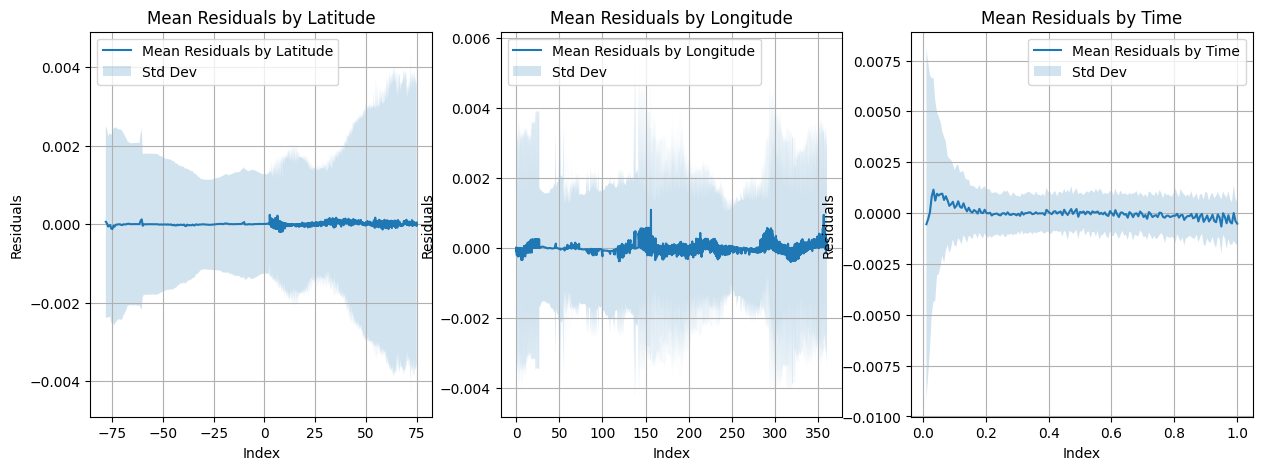

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(unique_latitude, resd_mean_by_lat, label='Mean Residuals by Latitude')
ax[0].fill_between(unique_latitude, resd_mean_by_lat - resd_std_by_lat, resd_mean_by_lat + resd_std_by_lat, alpha=0.2, label='Std Dev')
ax[0].set_title("Mean Residuals by Latitude")
ax[1].plot(np.unique(longitude), resd_mean_by_lon, label='Mean Residuals by Longitude')
ax[1].fill_between(np.unique(longitude), resd_mean_by_lon - resd_std_by_lon, resd_mean_by_lon + resd_std_by_lon, alpha=0.2, label='Std Dev')
ax[1].set_title("Mean Residuals by Longitude")
ax[2].plot(np.unique(time), resd_mean_by_time, label='Mean Residuals by Time')
ax[2].fill_between(np.unique(time), resd_mean_by_time - resd_std_by_time, resd_mean_by_time + resd_std_by_time, alpha=0.2, label='Std Dev')
ax[2].set_title("Mean Residuals by Time")
for i in range(3):
    ax[i].set_xlabel("Index")
    ax[i].set_ylabel("Residuals")
    ax[i].grid(True)
    ax[i].legend()

In [36]:
# --- helpers (only these two) ----------------------------------------------
def _mask_normalized_smooth(grid: np.ndarray, sigma: float, eps: float = 1e-12) -> np.ndarray:
    """
    Gaussian-smooth a 2D grid while respecting NaNs:
      - replace NaN with 0 for convolution
      - smooth the mask of finite cells
      - divide smoothed_values / smoothed_mask to get kernel-weighted average of observed cells
    Returns smoothed grid (NaN where insufficient mass).
    """
    filled = np.nan_to_num(grid, nan=0.0)
    mask = (~np.isnan(grid)).astype(float)
    sm = gaussian_filter(filled, sigma=sigma, mode='nearest')
    norm = gaussian_filter(mask, sigma=sigma, mode='nearest')
    with np.errstate(invalid='ignore', divide='ignore'):
        out = np.where(norm > eps, sm / norm, np.nan)
    return out

def checkerboard_masks(shape: Tuple[int, int],
                       mode: Literal["checkerboard", "subsample"] = "checkerboard",
                       offset: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (train_mask, val_mask) boolean arrays for a grid of given shape.
    - 'checkerboard': train = (i+j) % 2 == offset  (≈50% train / 50% val)
    - 'subsample'   : train = (i%2==offset & j%2==offset) (≈25% train, 25% val complementary)
    """
    nx, ny = shape
    ii, jj = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    if mode == "checkerboard":
        train = ((ii + jj) % 2 == (offset % 2))
        val = ~train
    elif mode == "subsample":
        train = ((ii % 2 == (offset % 2)) & (jj % 2 == (offset % 2)))
        val = ((ii % 2 == (1 - (offset % 2))) & (jj % 2 == (1 - (offset % 2))))
    else:
        raise ValueError("mode must be 'checkerboard' or 'subsample'")
    return train, val

# --- main function ---------------------------------------------------------
def smooth_variance_checkerboard_doublecv(
    X: Iterable[float],
    Y: Iterable[float],
    residuals: Iterable[float],
    desired_ppb: int = 100,
    sigma_candidates: Optional[Iterable[float]] = None,
    min_bins: int = 10,
    transformer: Optional[callable] = None,
    inv_transformer: Optional[callable] = None,
    score_on: Literal["mae", "mse"] = "mse",
    mode: Literal["checkerboard", "subsample"] = "checkerboard",
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """
    Checkerboard double CV for selecting gaussian smoothing sigma on a binned variance surface.

    Steps:
      - bin residual^2 into a regular grid (adaptive resolution from desired_ppb)
      - optionally transform per-bin variance with `transformer` (e.g. np.sqrt or np.log)
      - build train / val masks for both offsets (0 and 1)
      - for each sigma: smooth using *only training bins* (mask-normalized), evaluate on validation bins
      - combine losses from both offsets (weighted by valid counts), pick best sigma
      - refit final smoothed surface on ALL bins with best sigma and return results

    Returns:
      Xi, Yi         : meshgrid of bin centers (original X/Y units), shape (bins_x, bins_y)
      var_smooth_all : final smoothed variance grid (bins_x, bins_y) - NaN where undefined
      std_smooth_all : final smoothed std grid (bins_x, bins_y)
      best_sigma     : chosen sigma (in bin units)
    """
    # transformer pairing sanity
    assert (transformer is None and inv_transformer is None) or (transformer is not None and inv_transformer is not None), \
        "Either provide both transformer and inv_transformer or neither."
    if transformer is not None:
        test_arr = np.linspace(1.0, 10.0, 5)
        recon = inv_transformer(transformer(test_arr))
        np.testing.assert_allclose(test_arr, recon, rtol=1e-6, atol=1e-8)

    # inputs -> numpy arrays & basic checks
    X = np.asarray(X); Y = np.asarray(Y); R = np.asarray(residuals)
    if X.ndim != 1 or Y.ndim != 1 or R.ndim != 1:
        raise ValueError("X, Y, residuals must be 1D arrays")
    if not (len(X) == len(Y) == len(R)):
        raise ValueError("X, Y, residuals must have same length")
    N = len(X)
    if N == 0:
        raise ValueError("Empty inputs")

    if sigma_candidates is None:
        sigma_candidates = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]

    resid_sq = R**2

    # normalize coordinates to [0,1]
    Xmin, Xmax = X.min(), X.max()
    Ymin, Ymax = Y.min(), Y.max()
    if Xmax == Xmin or Ymax == Ymin:
        raise ValueError("Zero range on an axis")
    Xn = (X - Xmin) / (Xmax - Xmin)
    Yn = (Y - Ymin) / (Ymax - Ymin)

    # adaptive bin count from desired points-per-bin (keeps behavior robust to scale)
    uniq_x = len(np.unique(X)); uniq_y = len(np.unique(Y))
    density_x = uniq_x / N; density_y = uniq_y / N
    total_bins = max(float(N) / max(1, int(desired_ppb)), 1.0)
    denom = density_x + density_y
    ratio_x = 0.5 if denom <= 0 else density_x / denom
    ratio_y = 0.5 if denom <= 0 else density_y / denom
    bins_x = max(int(np.sqrt(total_bins * ratio_x)), min_bins)
    bins_y = max(int(np.sqrt(total_bins * ratio_y)), min_bins)

    # histogram -> per-bin variance (NaN if empty)
    x_edges = np.linspace(0.0, 1.0, bins_x + 1)
    y_edges = np.linspace(0.0, 1.0, bins_y + 1)
    sum_r2, _, _ = np.histogram2d(Xn, Yn, bins=[x_edges, y_edges], weights=resid_sq)
    counts, _, _ = np.histogram2d(Xn, Yn, bins=[x_edges, y_edges])
    with np.errstate(divide='ignore', invalid='ignore'):
        var_grid = np.where(counts > 0, sum_r2 / counts, np.nan)   # shape (bins_x, bins_y)

    # optionally transform per-bin variance (apply only on finite entries)
    if transformer is None:
        trans_grid = var_grid.copy()
    else:
        trans_grid = np.where(np.isfinite(var_grid), transformer(var_grid), np.nan)

    # build checkerboard/subsample masks for both offsets
    base_train0, base_val0 = checkerboard_masks((bins_x, bins_y), mode=mode, offset=0)
    base_train1, base_val1 = checkerboard_masks((bins_x, bins_y), mode=mode, offset=1)

    occupied = ~np.isnan(trans_grid)
    train_mask0 = base_train0 & occupied
    val_mask0 = base_val0 & occupied
    train_mask1 = base_train1 & occupied
    val_mask1 = base_val1 & occupied

    # ensure enough occupied train/val bins
    if train_mask0.sum() < 3 or val_mask0.sum() < 3 or train_mask1.sum() < 3 or val_mask1.sum() < 3:
        raise ValueError("Too few occupied train/val bins for one of the offsets. "
                         "Adjust desired_ppb, min_bins, or use different mode.")

    # CV loop: for each sigma compute predictions from training bins only (offset 0 & 1),
    # compute validation loss on validation bins, combine weighted by number of valid cells.
    combined_losses: List[float] = []
    losses0: List[float] = []
    losses1: List[float] = []
    best_sigma: Optional[float] = None
    best_combined = np.inf

    for sigma in sigma_candidates:
        # build training-only grids by setting non-train cells to NaN, then call helper to smooth
        grid_train0 = np.where(train_mask0, trans_grid, np.nan)
        pred0_trans = _mask_normalized_smooth(grid_train0, sigma=sigma)

        grid_train1 = np.where(train_mask1, trans_grid, np.nan)
        pred1_trans = _mask_normalized_smooth(grid_train1, sigma=sigma)

        # back-transform predictions to variance scale for scoring
        if transformer is None:
            pred0_var = pred0_trans
            pred1_var = pred1_trans
        else:
            pred0_var = np.where(np.isfinite(pred0_trans), inv_transformer(pred0_trans), np.nan)
            pred1_var = np.where(np.isfinite(pred1_trans), inv_transformer(pred1_trans), np.nan)

        # loss on validation bins (offset 0)
        p0 = pred0_var[val_mask0]; t0 = var_grid[val_mask0]
        valid0 = np.isfinite(p0) & np.isfinite(t0)
        if valid0.sum() == 0:
            loss0 = np.inf
        else:
            if score_on == "mae":
                loss0 = float(np.mean(np.abs(p0[valid0] - t0[valid0])))
            elif score_on == "mse":
                loss0 = float(np.mean((p0[valid0] - t0[valid0])**2))
            else:
                raise ValueError("score_on must be 'mae' or 'mse'")

        # loss on validation bins (offset 1)
        p1 = pred1_var[val_mask1]; t1 = var_grid[val_mask1]
        valid1 = np.isfinite(p1) & np.isfinite(t1)
        if valid1.sum() == 0:
            loss1 = np.inf
        else:
            if score_on == "mae":
                loss1 = float(np.mean(np.abs(p1[valid1] - t1[valid1])))
            elif score_on == "mse":
                loss1 = float(np.mean((p1[valid1] - t1[valid1])**2))

        count0 = int(valid0.sum())
        count1 = int(valid1.sum())
        if count0 + count1 == 0:
            combined = np.inf
        else:
            combined = (loss0 * count0 + loss1 * count1) / max(1, (count0 + count1))

        combined_losses.append(combined)
        losses0.append(loss0)
        losses1.append(loss1)

        if combined < best_combined:
            best_combined = combined
            best_sigma = float(sigma)

    if best_sigma is None:
        best_sigma = float(sigma_candidates[0])

    # final fit on ALL bins using best_sigma (smooth in transformed space then back-transform)
    final_trans = _mask_normalized_smooth(trans_grid, sigma=best_sigma)
    if transformer is None:
        var_smooth_all = final_trans
    else:
        var_smooth_all = np.where(np.isfinite(final_trans), inv_transformer(final_trans), np.nan)

    # compute std surface for output
    with np.errstate(invalid='ignore'):
        std_smooth_all = np.where(np.isfinite(var_smooth_all), np.sqrt(var_smooth_all), np.nan)

    # build meshgrid of bin centers in original coordinate units (indexing='ij' to match var_smooth shape)
    x_mid = (x_edges[:-1] + x_edges[1:]) / 2.0
    y_mid = (y_edges[:-1] + y_edges[1:]) / 2.0
    x_centers_orig = x_mid * (Xmax - Xmin) + Xmin
    y_centers_orig = y_mid * (Ymax - Ymin) + Ymin
    Xi, Yi = np.meshgrid(x_centers_orig, y_centers_orig, indexing='ij')

    # safety orientation fix
    if var_smooth_all.shape != Xi.shape:
        if var_smooth_all.T.shape == Xi.shape:
            var_smooth_all = var_smooth_all.T
            std_smooth_all = std_smooth_all.T
        else:
            raise RuntimeError("Shape reconciliation failed")

    return Xi, Yi, var_smooth_all, std_smooth_all, best_sigma

In [74]:
Xi, Yi, var_smooth_all, std_smooth_all, best_sigma = smooth_variance_checkerboard_doublecv(
    latitude, time, residuals, 10_000, score_on="mae", transformer=np.log, inv_transformer=np.exp
)
print(f"best sigma = {best_sigma}")

best sigma = 0.5


In [75]:
fig = go.Figure(
    data=[
        go.Surface(
            z=std_smooth_all,
            x=Xi,
            y=Yi,
            colorscale='Viridis'
        )
    ]
)

fig.update_layout(
    title='Smoothed Variance Surface',
    scene=dict(

        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Standar Deviation'
    ),
    autosize=True,
    width=800,
    height=700,
)

fig.show()

In [77]:
resd_std_by_lat

-78.2    0.002440
-77.6    0.002412
-77.1    0.002314
-76.5    0.002332
-76.0    0.002341
           ...   
 74.6    0.003738
 74.7    0.003646
 74.8    0.003576
 74.9    0.003572
 75.0    0.003751
Length: 908, dtype: float64

In [82]:
# indices
lat_vals = resd_std_by_lat.index.values
time_vals = resd_std_by_time.index.values

# values
lat_std = make_smoothing_spline(lat_vals, resd_std_by_lat.values)(lat_vals)

time_std = make_smoothing_spline(time_vals, resd_std_by_time.values)(time_vals)

# multiplicative + sqrt
Z = np.sqrt(np.outer(lat_std, time_std))  # shape (len(lat), len(time))


fig = go.Figure(
    data=go.Surface(
        x=np.tile(lat_vals[:, None], (1, len(time_vals))),
        y=np.tile(time_vals[None, :], (len(lat_vals), 1)),
        z=Z,
        colorscale="Viridis"
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="Latitude",
        yaxis_title="Time",
        zaxis_title="Std"
    ),
    title="3D Surface of Residual Std by Latitude and Time",
    autosize=True,
    width=800,
    height=700,
)

fig.show()
